In [6]:
#!pip install -q -U datasets bitsandbytes peft transformers accelerate Pillow


# Florence-2 Fine-tuning — Roboflow Dataset

Notebook upravený pre server s **32-core CPU, 128GB RAM, NVIDIA L40S 48GB**.
Pripravené špeciálne pre formát datasetu exportovaného z Roboflow pre model Florence-2.

## 1. Inštalácia závislostí a importy

## 2. Konfigurácia (Uprav cesty k datasetu)

In [1]:
from dotenv import load_dotenv
from roboflow import Roboflow
import os
import torch
import json
import os
from pathlib import Path
from PIL import Image
from transformers import AutoProcessor, AutoModelForCausalLM, TrainingArguments, Trainer
from peft import get_peft_model, LoraConfig, PeftModel
load_dotenv()

ROBOFLOW_API_KEY = os.getenv("RF_TOKEN")
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

project = rf.workspace("aienv").project("person-weapon-dataset-combined")
version = project.version(1)
dataset = version.download("florence2-od", location="dataset_florence")

loading Roboflow project...


## 3. Načítanie datasetu (Roboflow Formát)

In [2]:
# ==================== KONFIGURÁCIA ====================
# Nový dataset má train/valid/test foldery
TRAIN_JSONL   = "dataset_florence/train/annotations.jsonl"  # alebo _annotations.jsonl
TRAIN_IMAGES  = "dataset_florence/train/"
VALID_JSONL   = "dataset_florence/valid/annotations.jsonl"
VALID_IMAGES  = "dataset_florence/valid/"

MODEL_ID      = "microsoft/Florence-2-large-ft"
OUTPUT_DIR    = "florence2_weapon_finetune_v2"

NUM_EPOCHS    = 5
BATCH_SIZE    = 4
GRAD_ACCUM    = 8
LEARNING_RATE = 2e-5
# =======================================================

In [3]:
import re
import json
from pathlib import Path

def load_and_expand_dataset(jsonl_path: str, image_folder: str):
    records = []
    image_folder = Path(image_folder)

    det_pattern = re.compile(r'(\w+)(<loc_\d+><loc_\d+><loc_\d+><loc_\d+>)')

    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line: continue
            try:
                record = json.loads(line)
            except json.JSONDecodeError:
                continue

            image_file = record.get("image") or record.get("file_name")
            suffix = record.get("suffix") or ""
            if not image_file or not suffix: continue

            img_path = image_folder / image_file
            if not img_path.exists(): continue

            detections = det_pattern.findall(suffix)
            if not detections: continue

            by_label = {}
            for label, coords in detections:
                if label.lower() not in ("weapon", "person"):
                    continue
                by_label.setdefault(label, []).append(f"{label}{coords}")

            for label, parts in by_label.items():
                records.append({
                    "image_path": str(img_path),
                    "prefix": f"detect {label};",
                    "suffix": "".join(parts)
                })

    weapon_count = sum(1 for r in records if "weapon" in r["prefix"])
    person_count = sum(1 for r in records if "person" in r["prefix"])
    print(f"Načítaných {len(records)} záznamov | weapon: {weapon_count} | person: {person_count}")
    return records

# Načítaj train a valid zvlášť — nepotrebuješ shuffle+split
train_data = load_and_expand_dataset(TRAIN_JSONL, TRAIN_IMAGES)
val_data   = load_and_expand_dataset(VALID_JSONL, VALID_IMAGES)
print(f"Train: {len(train_data)} | Val: {len(val_data)}")
print("Ukážka:", {k: v for k, v in train_data[0].items() if k != 'image_path'})

Načítaných 42859 záznamov | weapon: 33693 | person: 9166
Načítaných 779 záznamov | weapon: 578 | person: 201
Train: 42859 | Val: 779
Ukážka: {'prefix': 'detect weapon;', 'suffix': 'weapon<loc_647><loc_356><loc_677><loc_414>'}


## 4. Inicializácia Modelu a Processora (obsahuje fix pre Transformers)

In [14]:
import torch
import torch.nn as nn
from transformers import AutoModelForCausalLM, AutoProcessor
from transformers.configuration_utils import PretrainedConfig

# 1. TOTO JE KRITICKÉ PRE LARGE VERZIU (Oprava chýb v transformers 4.49)
PretrainedConfig.forced_bos_token_id = None
nn.Module._supports_sdpa = False
nn.Module._supports_flash_attn_2 = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_ID = "microsoft/Florence-2-large-ft"
# Definujeme DTYPE, aby ti nepadol collate_fn neskôr
DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32

print("Načítavam Large model (bez pr/6)...")

# 2. Načítanie bez problematickej revízie
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    torch_dtype=DTYPE,
    attn_implementation="eager" # Toto nahradzuje opravu z pr/6
).to(device)

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    trust_remote_code=True
)
new_tokens = ["detect weapon;", "detect person;"]
processor.tokenizer.add_tokens(new_tokens)
model.resize_token_embeddings(len(processor.tokenizer))
print(f"Tokenizer rozšírený o {len(new_tokens)} tokenov")

print("✅ Large model je v pamäti a pripravený na tréning.")

Tokenizer rozšírený o 2 tokenov
✅ Large model je v pamäti a pripravený na tréning.


## 5. Collate Funkcia pre Florence-2

In [15]:
def collate_fn(batch):
    prompts = []
    answers = []
    images = []
    
    for ex in batch:
        try:
            img = Image.open(ex["image_path"]).convert("RGB")
        except:
            continue
        images.append(img)
        prompts.append(ex["prefix"])
        answers.append(ex["suffix"])
        
    if not images: return None

    # Zabalíme obrázky a prompty
    inputs = processor(
        text=prompts, 
        images=images, 
        return_tensors="pt", 
        padding=True
    )
    
    # Zabalíme správne odpovede (tzv. labels)
    labels = processor.tokenizer(
        text=answers, 
        return_tensors="pt", 
        padding=True, 
        return_attention_mask=False
    )["input_ids"]
    
    # Maskovanie padding tokenov, aby sa z nich model neučil (-100 v PyTorchi znamená "ignoruj")
    labels[labels == processor.tokenizer.pad_token_id] = -100
    inputs["labels"] = labels
    
    # Presun obrazových matíc do správneho dátového typu
    inputs["pixel_values"] = inputs["pixel_values"].to(DTYPE)
    
    return inputs

print("Collate funkcia pripravená.")

Collate funkcia pripravená.


## 6. Tréning

In [ ]:
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    weight_decay=1e-6,
    adam_beta2=0.999,
    warmup_ratio=0.03,
    bf16=True,                       
    tf32=True,                       
    optim="adamw_torch_fused",       
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    remove_unused_columns=False,     # Nutné pre custom collate_fn
    dataloader_num_workers=0,        
    dataloader_pin_memory=False,     
    report_to=["tensorboard"],
    run_name="florence2-weapon-finetunev2",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_data,   # list záznamov z load_and_expand_dataset
    eval_dataset=val_data,      # list záznamov z load_and_expand_dataset
    data_collator=collate_fn,
)

print("Spúšťam tréning Florence-2...")
trainer.train()

Epoch,Training Loss,Validation Loss


## 7. Uloženie

In [7]:
import os
import torch
import torch.nn as nn
from transformers import AutoModelForCausalLM, AutoProcessor, AutoConfig
from transformers.configuration_utils import PretrainedConfig

# 1. FIX PRE TRANSFORMERS
PretrainedConfig.forced_bos_token_id = None
nn.Module._supports_sdpa = False
nn.Module._supports_flash_attn_2 = False

ORIGINAL_MODEL_ID = "microsoft/Florence-2-large-ft"
CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, "checkpoint-6695")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32

print("1. Načítavam čistý config a procesor...")
clean_config = AutoConfig.from_pretrained(ORIGINAL_MODEL_ID, trust_remote_code=True)
processor = AutoProcessor.from_pretrained(ORIGINAL_MODEL_ID, trust_remote_code=True)

# Pridáme tokeny do procesora hneď na začiatku
added_tokens = ["person", "weapon"]
processor.tokenizer.add_tokens(added_tokens)

print("2. Načítavam model s povolením zmeny veľkosti (ignore_mismatched_sizes)...")
# TENTO KROK JE KĽÚČOVÝ:
# Načítame model priamo z checkpointu, ale podstrčíme mu čistý config.
# ignore_mismatched_sizes=True zabezpečí, že sa embeddingy prispôsobia tvojim váham (51291)
model = AutoModelForCausalLM.from_pretrained(
    CHECKPOINT_PATH,
    config=clean_config,
    trust_remote_code=True,
    torch_dtype=DTYPE,
    ignore_mismatched_sizes=True, # <--- Toto vyrieši ten RuntimeError
    attn_implementation="eager"
).to(device)

# Pre istotu synchronizujeme veľkosť embeddingov s procesorom
model.resize_token_embeddings(len(processor.tokenizer))

model.eval()

print(f"3. Ukladám finálnu verziu do: {OUTPUT_DIR}")
model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)

print("✅ HOTOVO! Model je opravený a pripravený.")

✅ HOTOVO! Model je opravený a pripravený.


## 8. Inferencia (Otestovanie Modelu)

In [8]:
inf_processor = AutoProcessor.from_pretrained(OUTPUT_DIR, trust_remote_code=True)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=torch.bfloat16, trust_remote_code=True, device_map="auto"
)

# Hack pre inferenciu
if hasattr(base_model.config, 'text_config') and not hasattr(base_model.config.text_config, 'forced_bos_token_id'):
    base_model.config.text_config.forced_bos_token_id = None
if not hasattr(base_model.config, 'forced_bos_token_id'):
    base_model.config.forced_bos_token_id = None

inf_model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
inf_model.eval()

def predict_florence(image_path, prompt="<OD>"):
    img = Image.open(image_path).convert("RGB")
    inputs = inf_processor(text=prompt, images=img, return_tensors="pt").to(device, DTYPE)

    with torch.no_grad():
        generated_ids = inf_model.generate(
            input_ids=inputs["input_ids"],
            pixel_values=inputs["pixel_values"],
            max_new_tokens=512,
            num_beams=3,
        )

    generated_text = inf_processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    
    # Florence post-processing konvertuje tokeny späť na súradnice
    parsed_answer = inf_processor.post_process_generation(
        generated_text, 
        task=prompt, 
        image_size=(img.width, img.height)
    )
    return parsed_answer

# Test
if val_data:
    sample = val_data[0]
    print(f"Testujem obrázok: {sample['image_path']}")
    vysledok = predict_florence(sample['image_path'], prompt="<OD>")
    print("\nDetekcie:", vysledok)

ValueError: Florence2ForConditionalGeneration does not support `device_map='auto'`. To implement support, the model class needs to implement the `_no_split_modules` attribute.

In [9]:
import os, torch, torch.nn as nn
from transformers import AutoModelForCausalLM, AutoProcessor, AutoConfig
from transformers.configuration_utils import PretrainedConfig

PretrainedConfig.forced_bos_token_id = None
nn.Module._supports_sdpa = False
nn.Module._supports_flash_attn_2 = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32

ORIGINAL_MODEL_ID = "microsoft/Florence-2-large-ft"
CHECKPOINT_PATH = "florence2_weapon_finetune_v2/checkpoint-6695"
# Ak checkpoint-2684 neexistuje, skús checkpoint-3350 alebo len OUTPUT_DIR
# Zisti čo máš: os.listdir("florence2_weapon_finetune")

# --- BASE MODEL ---
print("Načítavam base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    ORIGINAL_MODEL_ID,
    trust_remote_code=True,
    torch_dtype=DTYPE,
    attn_implementation="eager"
).to(device)
base_processor = AutoProcessor.from_pretrained(ORIGINAL_MODEL_ID, trust_remote_code=True)

# --- FINETUNED MODEL ---
print("Načítavam finetuned model...")
# Čistý config z originálu, váhy z checkpointu
clean_config = AutoConfig.from_pretrained(ORIGINAL_MODEL_ID, trust_remote_code=True)

inf_model = AutoModelForCausalLM.from_pretrained(
    CHECKPOINT_PATH,
    config=clean_config,          # <-- čistý config, nie ten uložený
    trust_remote_code=True,
    torch_dtype=DTYPE,
    attn_implementation="eager",
    ignore_mismatched_sizes=False
).to(device)
inf_processor = AutoProcessor.from_pretrained(ORIGINAL_MODEL_ID, trust_remote_code=True)

base_model.eval()
inf_model.eval()
print("✅ Oba modely načítané!")

RuntimeError: Error(s) in loading state_dict for Florence2ForConditionalGeneration:
	size mismatch for language_model.final_logits_bias: copying a param with shape torch.Size([1, 51291]) from checkpoint, the shape in current model is torch.Size([1, 51289]).
	size mismatch for language_model.model.shared.weight: copying a param with shape torch.Size([51291, 1024]) from checkpoint, the shape in current model is torch.Size([51289, 1024]).
	You may consider adding `ignore_mismatched_sizes=True` in the model `from_pretrained` method.

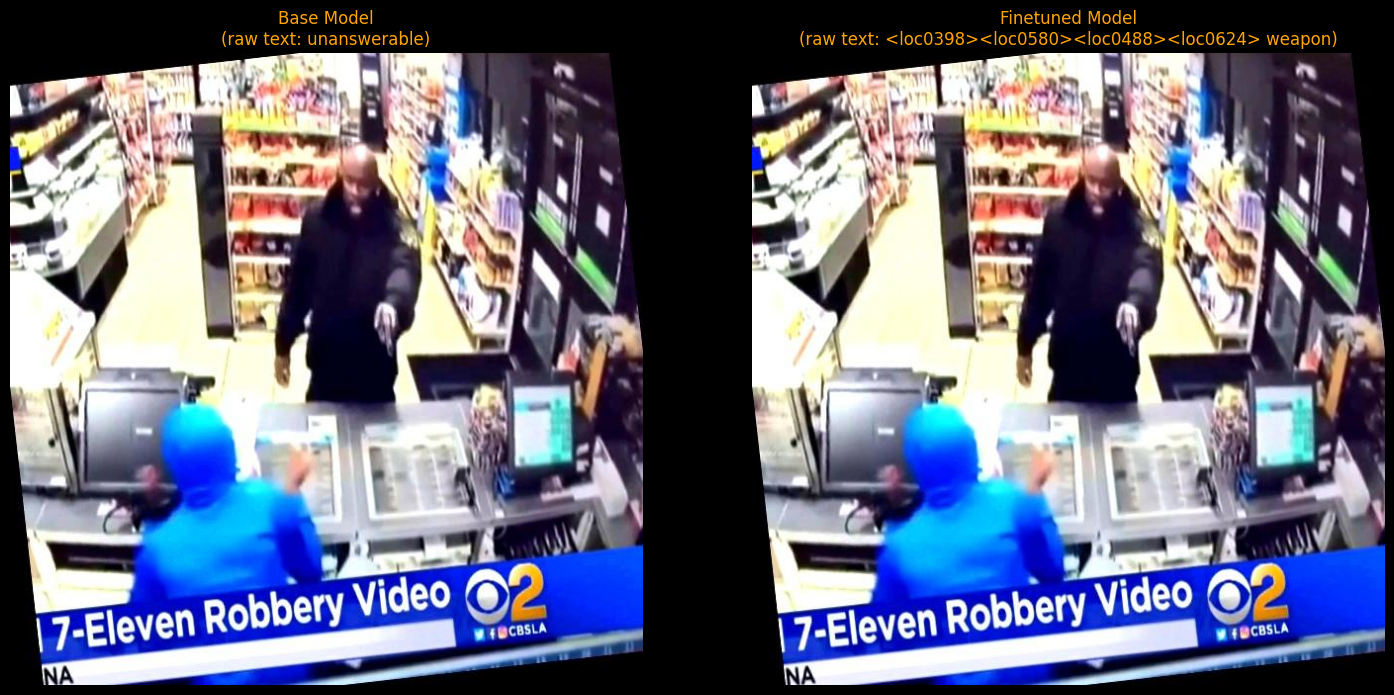

In [21]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch

# OPRAVA 1: Správne názvy premenných z notebooku
# base = pôvodný model (model, processor)
# ft   = finetuned model (inf_model, inf_processor)

def get_predictions(mdl, proc, image, prompt):
    inputs = proc(text=prompt, images=image, return_tensors="pt").to(device, DTYPE)
    with torch.no_grad():
        generated_ids = mdl.generate(
            input_ids=inputs["input_ids"],
            pixel_values=inputs["pixel_values"],
            max_new_tokens=512,
            num_beams=3,
        )
    generated_text = proc.batch_decode(generated_ids, skip_special_tokens=False)[0]
    print(f"RAW výstup: {generated_text[:200]}")  # debug

    parsed_answer = proc.post_process_generation(
        generated_text, task=prompt, image_size=(image.width, image.height)
    )
    print(f"Parsed: {parsed_answer}")  # debug
    return parsed_answer

def draw_boxes(ax, image, data, title, prompt):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

    # OPRAVA 2: Skúšame všetky možné kľúče
    res = data.get(prompt) or data.get("<OD>") or (list(data.values())[0] if data else None)

    if res is None:
        ax.set_title(f"{title}\n(žiadne detekcie)", color='red')
        return

    # OPRAVA 3: res môže byť string namiesto dict (ak prompt nebol rozpoznaný)
    if isinstance(res, str):
        ax.set_title(f"{title}\n(raw text: {res[:50]})", color='orange')
        return

    bboxes = res.get("bboxes", [])
    labels = res.get("labels", [])

    if not bboxes:
        ax.set_title(f"{title}\n(0 detekcií)", color='orange')
        return

    for bbox, label in zip(bboxes, labels):
        x1, y1, x2, y2 = bbox
        color = 'red' if 'weapon' in label.lower() else 'lime'
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                 linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1, label, color='white', fontsize=8,
                bbox=dict(facecolor=color, alpha=0.5))

# OPRAVA 4: Správne premenné — model/processor (base) a inf_model/inf_processor (ft)
# Prompt musí byť rovnaký ako pri tréningu
TARGET_PROMPT = "detect person ; weapon"  # alebo skús "<OD>" ak toto nefunguje

samples = random.sample(val_data, 2)
for sample in samples:
    img = Image.open(sample['image_path']).convert("RGB")
    print(f"\n--- Obrázok: {sample['image_path']} ---")

    base_res = get_predictions(model, processor, img, TARGET_PROMPT)
    ft_res   = get_predictions(inf_model, inf_processor, img, TARGET_PROMPT)

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    draw_boxes(axes[0], img, base_res, "Base Model", TARGET_PROMPT)
    draw_boxes(axes[1], img, ft_res,   "Finetuned Model", TARGET_PROMPT)
    plt.tight_layout()
    plt.show()

In [5]:
import json

# 1. Oprav config.json priamo
config_path = "florence2_weapon_finetune_v2/config.json"
with open(config_path) as f:
    cfg = json.load(f)

print("PRED opravou:", cfg.get("vision_config", {}).get("model_type"))

# Nastav správny model_type
cfg["vision_config"]["model_type"] = "davit"

with open(config_path, "w") as f:
    json.dump(cfg, f, indent=2)

print("PO oprave:", cfg["vision_config"]["model_type"])
print("✅ config.json opravený")

# 2. Načítaj model znovu — už bez clean_config ani ignore_mismatched_sizes
model = AutoModelForCausalLM.from_pretrained(
    OUTPUT_DIR,
    trust_remote_code=True,
    torch_dtype=DTYPE,
    attn_implementation="eager",
).to(device)
model.eval()
print("✅ Model načítaný správne!")

# 3. Hneď otestuj
raw = processor.batch_decode(
    model.generate(
        **processor(text="detect weapon;", images=img, return_tensors="pt").to(device, DTYPE),
        max_new_tokens=512, num_beams=3
    ), skip_special_tokens=False
)[0]
print("RAW OUTPUT:", raw)

ValueError: Attention mask should be of size (1, 1, 584, 584), but is torch.Size([1, 1, 7, 7])

In [7]:
import json, torch, torch.nn as nn
from transformers import AutoModelForCausalLM, AutoProcessor, AutoConfig
from transformers.configuration_utils import PretrainedConfig

PretrainedConfig.forced_bos_token_id = None
nn.Module._supports_sdpa = False
nn.Module._supports_flash_attn_2 = False

ORIGINAL_MODEL_ID = "microsoft/Florence-2-large-ft"
CHECKPOINT_PATH   = "florence2_weapon_finetune_v2/checkpoint-6695"
OUTPUT_DIR        = "florence2_weapon_finetune_v2"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE  = torch.bfloat16 if torch.cuda.is_available() else torch.float32

# 1. Config z originálu
clean_config = AutoConfig.from_pretrained(ORIGINAL_MODEL_ID, trust_remote_code=True)

# 2. Processor z originálu + pridaj rovnaké tokeny ako pri tréningu
processor = AutoProcessor.from_pretrained(ORIGINAL_MODEL_ID, trust_remote_code=True)
processor.tokenizer.add_tokens(["detect weapon;", "detect person;"])
print(f"Tokenizer veľkosť: {len(processor.tokenizer)}")  # musí byť 51291

# 3. Uprav vocab_size v configu aby sedel s checkpointom
clean_config.text_config.vocab_size = len(processor.tokenizer)  # 51291
clean_config.vocab_size = len(processor.tokenizer)

# 4. Načítaj model z checkpointu — teraz sa rozmery zhodujú
model = AutoModelForCausalLM.from_pretrained(
    CHECKPOINT_PATH,
    config=clean_config,
    trust_remote_code=True,
    torch_dtype=DTYPE,
    attn_implementation="eager",
    ignore_mismatched_sizes=False,  # False — chceme error ak nesedí
).to(device)
model.eval()
print("✅ Model načítaný!")

# 5. Test
test_img_path = val_images[0]
img = Image.open(test_img_path).convert("RGB")

for prompt in ["detect weapon;", "detect person;"]:
    inputs = processor(text=prompt, images=img, return_tensors="pt").to(device, DTYPE)
    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=inputs["input_ids"],
            pixel_values=inputs["pixel_values"],
            max_new_tokens=512,
            num_beams=3,
        )
    raw = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    print(f"\nPROMPT: {prompt}")
    print(f"RAW: {raw}")


PROMPT: detect person;
RAW: </s><s><s><s>person<loc_358><loc_130><loc_595><loc_830></s>


In [8]:
def parse_raw_locs(raw_text, img_w, img_h):
    """
    Parsuje formát: person<loc_358><loc_130><loc_595><loc_830>
    Hodnoty sú 0-999, normalizované na rozmery obrázka.
    """
    # Odfiltruj špeciálne tokeny
    raw_text = raw_text.replace("</s>", "").replace("<s>", "").replace("<pad>", "").strip()

    pattern = re.compile(r"(weapon|person)<loc_(\d+)><loc_(\d+)><loc_(\d+)><loc_(\d+)>")
    bboxes, labels = [], []
    for label, x1n, y1n, x2n, y2n in pattern.findall(raw_text):
        bboxes.append([
            int(x1n) / 999 * img_w,
            int(y1n) / 999 * img_h,
            int(x2n) / 999 * img_w,
            int(y2n) / 999 * img_h,
        ])
        labels.append(label)
    return {"bboxes": bboxes, "labels": labels}


def predict(image_path, prompt):
    img = Image.open(image_path).convert("RGB")
    inputs = processor(text=prompt, images=img, return_tensors="pt").to(device, DTYPE)

    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=inputs["input_ids"],
            pixel_values=inputs["pixel_values"],
            max_new_tokens=512,
            num_beams=3,
        )

    raw = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    print(f"  RAW [{prompt}]: {raw[:150]}")

    # Priamo parsuj raw output — post_process_generation nefunguje pre custom prompty
    result = parse_raw_locs(raw, img.width, img.height)
    return result


# ── Test loop ──────────────────────────────────────────────
samples = random.sample(val_images, min(N_SAMPLES, len(val_images)))

cols = 3
rows = (len(samples) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5))
axes = axes.flatten()

for ax_idx, img_path in enumerate(samples):
    print("[" + str(ax_idx + 1) + "/" + str(len(samples)) + "] " + Path(img_path).name)
    all_detections = []
    for prompt in PROMPTS:
        det = predict(img_path, prompt)
        n = len(det.get("bboxes", []))
        print(f"  -> {prompt}: {n} detekcii")
        all_detections.append((prompt, det))
    draw_results(axes[ax_idx], img_path, all_detections)

for ax in axes[len(samples):]:
    ax.set_visible(False)

plt.suptitle("Florence-2 Finetuned — " + OUTPUT_DIR, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("test_results.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Hotovo!")

✅ Hotovo!
